<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%201/Week_1_Lecture_6_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=QdM-QariW30) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%201/DL4CV_Week01_Part06.pdf)

In [ ]:
# Week 1, Lecture 6: Image in frequency domain
from IPython.display import HTML, display

VIDEO_ID = "QdM-QariW30"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

Watch on YouTube

# Week 1, Lecture 6: Image in the Frequency Domain

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§1.6 Frequency Domain**.

**What you will learn**

- Build signals from sines and read an image's **Fourier spectrum**.
- Understand the discrete transform and the cost saving of the **FFT**.
- Use the **convolution theorem**: convolution in space is multiplication in frequency.
- Apply **low-pass** and **high-pass** filtering in the frequency domain.
- Compare what **magnitude** and **phase** each carry, and build **hybrid images** from that difference.

**Contents**
1. Is correlation still useful? Template matching
2. Beyond linear filters: median and bilateral
3. Building signals from sines
4. Fourier analysis of images
5. Continuous vs discrete, and the cost of the FFT
6. The convolution theorem
7. Properties of the Fourier transform
8. Low-pass and high-pass filtering in the frequency domain
9. Which carries more: magnitude or phase?
10. Hybrid images
11. Exercise: match each image to its spectrum

**How to run**  Runs on Colab or a local Jupyter, CPU only. Every image is bundled with `scikit-image`, so nothing is downloaded. Run the setup cell first, then go top to bottom.

## Review

The previous lecture treated filtering in the **spatial domain**: each output pixel is a weighted sum of a
local neighbourhood (cross-correlation), and convolution is the same operation with a flipped kernel. Two
questions were left open: is correlation useful on its own, and are all useful filters linear? This lecture
answers both, then changes coordinates. Viewing an image as a sum of sinusoids (its **Fourier transform**)
turns convolution into multiplication and exposes the scales and orientations present in an image.

## Setup

Everything uses images bundled with `scikit-image`, so the notebook runs offline.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import data, util, color

np.random.seed(0)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['image.cmap']     = 'gray'
plt.rcParams['figure.dpi']     = 85

def log_mag(im):
    # centred log magnitude spectrum, suitable for display
    return np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(im))))

def load_gray(image, size=None):
    # float grayscale image, optionally resized to (size, size)
    g = color.rgb2gray(image) if image.ndim == 3 else util.img_as_float(image)
    if size is not None:
        from skimage.transform import resize
        g = resize(g, (size, size))
    return g

def show(ax, im, title='', spectrum=False):
    ax.imshow(im, cmap='magma' if spectrum else 'gray')
    ax.set_title(title); ax.axis('off')

## 1. Is correlation still useful? Template matching

Correlation is the core of **template matching**: slide a small template over an image and score how well it
matches at each location. Raw correlation rewards bright regions regardless of shape, so we use **normalised
cross-correlation**, which subtracts the local mean and divides by the local standard deviation:

$$\text{NCC}(i,j) = \frac{\sum_{u,v}\big(T(u,v)-\bar T\big)\big(I(i+u,j+v)-\bar I_{i,j}\big)}
{\sqrt{\sum_{u,v}\big(T(u,v)-\bar T\big)^2 \; \sum_{u,v}\big(I(i+u,j+v)-\bar I_{i,j}\big)^2}}$$

The score lies in $[-1, 1]$ and peaks wherever the pattern appears. `skimage.feature.match_template` computes it.

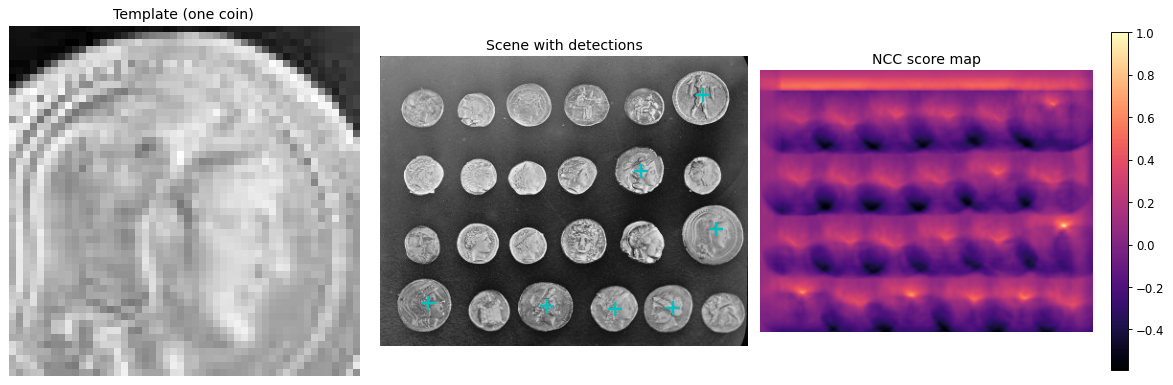

detections: 7    best score: 1.000


In [2]:
from skimage.feature import match_template, peak_local_max

scene    = data.coins().astype(float)
template = scene[155:205, 325:375]                 # one coin, used as the pattern to find
ncc      = match_template(scene, template, pad_input=True)
peaks    = peak_local_max(ncc, min_distance=20, threshold_abs=0.45)

fig, ax = plt.subplots(1, 3, figsize=(14, 4.5))
show(ax[0], template, 'Template (one coin)')
show(ax[1], scene, 'Scene with detections')
ax[1].plot(peaks[:, 1], peaks[:, 0], 'c+', ms=12, mew=2)
im = ax[2].imshow(ncc, cmap='magma'); ax[2].set_title('NCC score map'); ax[2].axis('off')
fig.colorbar(im, ax=ax[2], fraction=0.046)
plt.tight_layout(); plt.show()

print(f'detections: {len(peaks)}    best score: {ncc.max():.3f}')

## 2. Beyond linear filters: median and bilateral

Not every useful filter is linear. The **median filter** replaces each pixel by the median of its
neighbourhood, which discards outliers, so it removes salt-and-pepper noise that linear smoothers only spread.
The **bilateral filter** is a non-linear, edge-preserving smoother: it averages neighbours but down-weights
those whose intensity differs from the centre, combining a spatial (domain) kernel with an intensity (range)
kernel:

$$w(i,j,k,l) = \exp\!\left(-\frac{(i-k)^2+(j-l)^2}{2\sigma_d^2}\right)
\,\exp\!\left(-\frac{\lVert I(i,j)-I(k,l)\rVert^2}{2\sigma_r^2}\right)$$

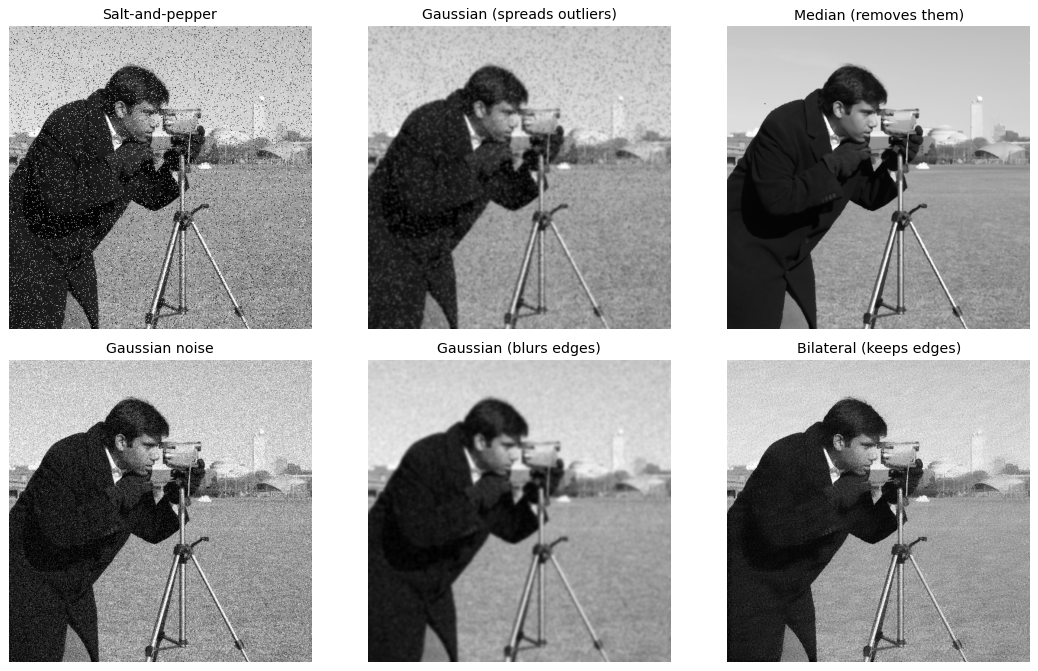

In [3]:
from skimage.restoration import denoise_bilateral

img = load_gray(data.camera())
sp  = util.random_noise(img, mode='s&p', amount=0.08)        # salt-and-pepper
gn  = util.random_noise(img, mode='gaussian', var=0.01)      # additive Gaussian

fig, ax = plt.subplots(2, 3, figsize=(13, 8))
show(ax[0, 0], sp, 'Salt-and-pepper')
show(ax[0, 1], ndimage.gaussian_filter(sp, 1.5), 'Gaussian (spreads outliers)')
show(ax[0, 2], ndimage.median_filter(sp, size=3), 'Median (removes them)')
show(ax[1, 0], gn, 'Gaussian noise')
show(ax[1, 1], ndimage.gaussian_filter(gn, 2), 'Gaussian (blurs edges)')
show(ax[1, 2], denoise_bilateral(gn, sigma_color=0.1, sigma_spatial=3), 'Bilateral (keeps edges)')
plt.tight_layout(); plt.show()

## 3. Building signals from sines

Fourier's idea: any reasonable signal is a weighted sum of sinusoids $A\sin(\omega x + \phi)$ of different
frequencies. A square wave, for example, is the sum of its odd harmonics with amplitudes $1/k$:

$$f(t) = \frac{4}{\pi}\sum_{k=1,3,5,\dots} \frac{1}{k}\,\sin(2\pi k t)$$

The **magnitude spectrum** (amplitude versus frequency) makes the recipe explicit: one spike per frequency
present. Adding more harmonics sharpens the wave but leaves a fixed overshoot at each jump, the **Gibbs
phenomenon**.

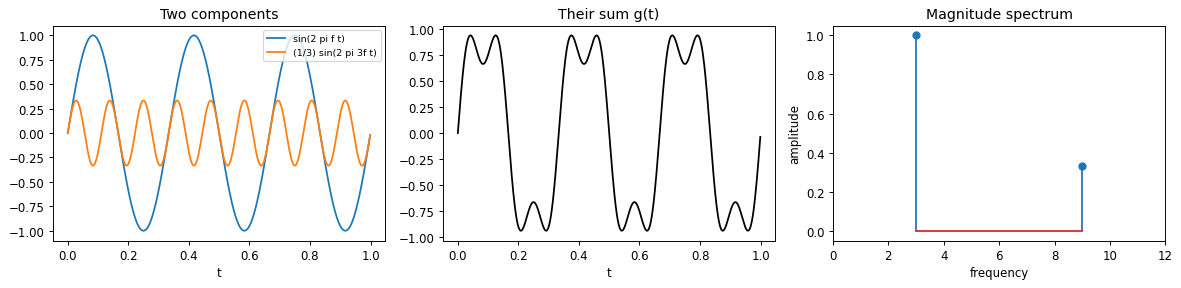

In [4]:
# A two-component example: g(t) = sin(2 pi f t) + (1/3) sin(2 pi 3f t)
t = np.linspace(0, 1, 1000, endpoint=False)
f = 3
g = np.sin(2*np.pi*f*t) + (1/3)*np.sin(2*np.pi*(3*f)*t)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
ax[0].plot(t, np.sin(2*np.pi*f*t), label='sin(2 pi f t)')
ax[0].plot(t, (1/3)*np.sin(2*np.pi*3*f*t), label='(1/3) sin(2 pi 3f t)')
ax[0].legend(fontsize=8); ax[0].set_title('Two components'); ax[0].set_xlabel('t')
ax[1].plot(t, g, 'k'); ax[1].set_title('Their sum g(t)'); ax[1].set_xlabel('t')
ax[2].stem([f, 3*f], [1, 1/3]); ax[2].set_xlim(0, 12)
ax[2].set_xlabel('frequency'); ax[2].set_ylabel('amplitude'); ax[2].set_title('Magnitude spectrum')
plt.tight_layout(); plt.show()

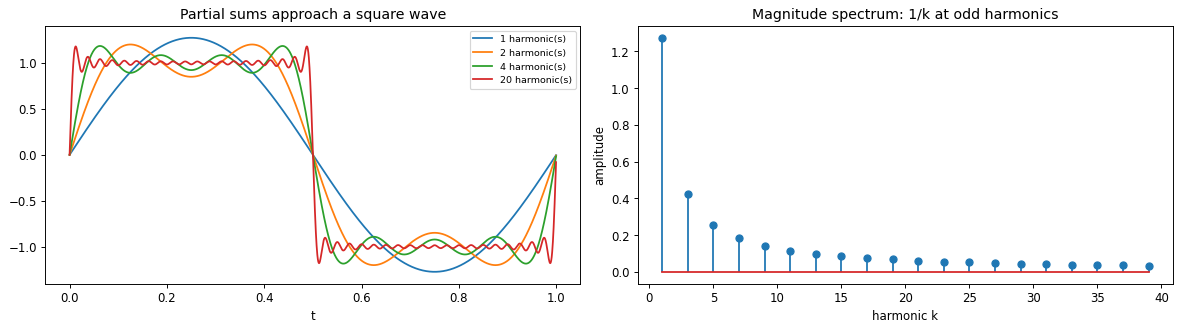

Gibbs overshoot: partial-sum peak = 1.179 (target 1.0)


In [5]:
# Build a square wave from its odd harmonics and watch the Gibbs overshoot
t = np.linspace(0, 1, 2000, endpoint=False)
def square_partial(n_harm):
    s = sum((1/k)*np.sin(2*np.pi*k*t) for k in range(1, 2*n_harm, 2))
    return (4/np.pi)*s

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for n in [1, 2, 4, 20]:
    ax[0].plot(t, square_partial(n), label=f'{n} harmonic(s)')
ax[0].legend(fontsize=8); ax[0].set_xlabel('t')
ax[0].set_title('Partial sums approach a square wave')

ks = np.arange(1, 40, 2)
ax[1].stem(ks, (4/np.pi)/ks)
ax[1].set_xlabel('harmonic k'); ax[1].set_ylabel('amplitude')
ax[1].set_title('Magnitude spectrum: 1/k at odd harmonics')
plt.tight_layout(); plt.show()

print(f'Gibbs overshoot: partial-sum peak = {square_partial(50).max():.3f} (target 1.0)')

## 4. Fourier analysis of images

The 2D Fourier transform writes an image as a sum of 2D sinusoidal gratings. A single grating transforms to a
**pair of symmetric peaks**: their distance from the centre encodes spatial frequency and their direction
encodes orientation, with the **DC term** (average brightness) at the centre. Each frequency stores a complex
value, summarised as

$$\text{magnitude } A = \sqrt{\text{Re}^2 + \text{Im}^2}, \qquad \text{phase } \phi = \tan^{-1}\!\frac{\text{Im}}{\text{Re}}$$

For real images the spectrum is conjugate-symmetric, which is the mirror symmetry seen below.

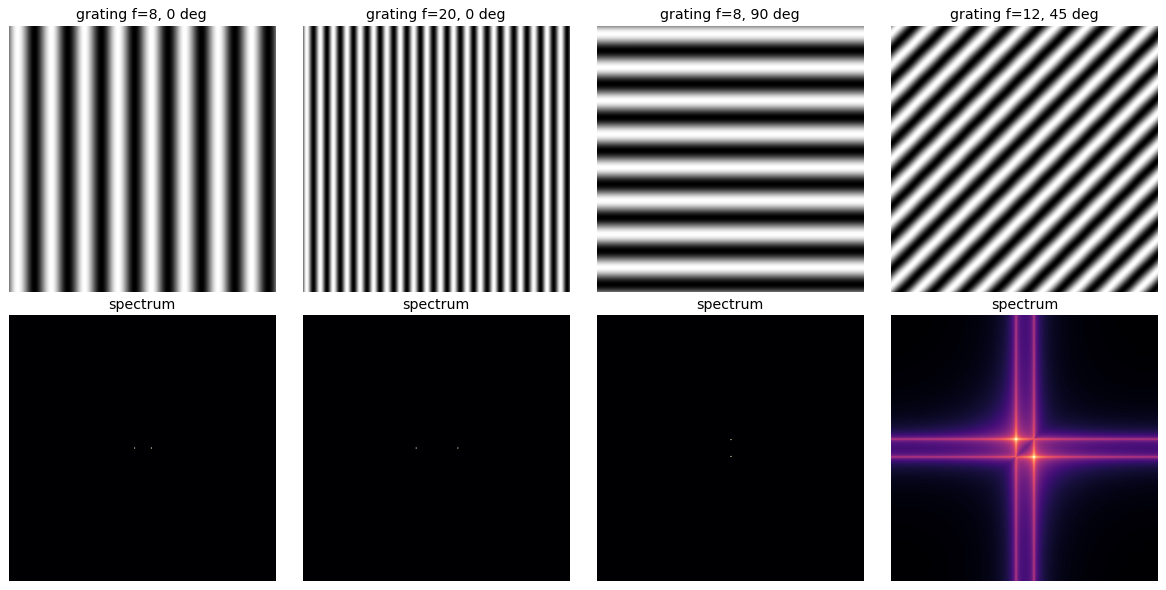

In [6]:
N = 256
yy, xx = np.mgrid[0:N, 0:N]
def grating(freq, theta_deg):
    th = np.deg2rad(theta_deg)
    return np.sin(2*np.pi*freq*(xx*np.cos(th) + yy*np.sin(th))/N)

cases = [(8, 0), (20, 0), (8, 90), (12, 45)]
fig, ax = plt.subplots(2, 4, figsize=(14, 7))
for j, (fr, th) in enumerate(cases):
    g = grating(fr, th)
    show(ax[0, j], g, f'grating f={fr}, {th} deg')
    show(ax[1, j], log_mag(g), 'spectrum', spectrum=True)
plt.tight_layout(); plt.show()

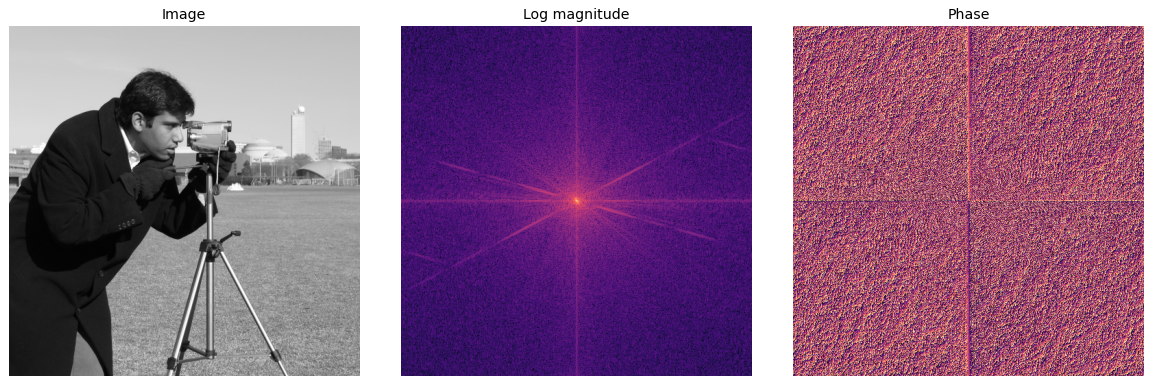

In [7]:
# Magnitude and phase of a real image (note the mirror symmetry in the magnitude)
img = load_gray(data.camera())
F   = np.fft.fftshift(np.fft.fft2(img))

fig, ax = plt.subplots(1, 3, figsize=(14, 4.5))
show(ax[0], img, 'Image')
show(ax[1], np.log1p(np.abs(F)), 'Log magnitude', spectrum=True)
show(ax[2], np.angle(F), 'Phase', spectrum=True)
plt.tight_layout(); plt.show()

## 5. Continuous vs discrete, and the cost of the FFT

The continuous transform integrates over all space; for sampled signals we use the **Discrete Fourier
Transform (DFT)**:

$$H(k) = \sum_{n=0}^{N-1} h(n)\, e^{-j 2\pi k n / N}$$

Computed directly this is a matrix-vector product costing $O(N^2)$. The **Fast Fourier Transform (FFT)** is a
recursive divide-and-conquer algorithm that returns the same result in $O(N \log N)$. The speed-up below is
what makes frequency-domain image processing practical.

In [8]:
import time

def naive_dft(x):
    n = len(x); k = np.arange(n)
    W = np.exp(-2j*np.pi*np.outer(k, k)/n)      # explicit N x N DFT matrix
    return W @ x

x = np.random.rand(512)
print('max |naive - np.fft|:', np.abs(naive_dft(x) - np.fft.fft(x)).max())
print()
print(f"{'N':>6}  {'naive O(N^2)':>14}  {'FFT O(N log N)':>16}")
for n in [128, 256, 512, 1024]:
    x = np.random.rand(n)
    t0 = time.perf_counter(); naive_dft(x);  t1 = time.perf_counter()
    t2 = time.perf_counter(); np.fft.fft(x); t3 = time.perf_counter()
    print(f"{n:>6}  {1e3*(t1-t0):>11.2f} ms  {1e6*(t3-t2):>13.2f} us")

max |naive - np.fft|: 6.467697017861789e-12

     N    naive O(N^2)    FFT O(N log N)
   128         0.69 ms          35.05 us
   256         2.06 ms          36.02 us
   512         7.50 ms          42.34 us
  1024        42.79 ms          66.37 us


## 6. The convolution theorem

The Fourier transform turns convolution into a pointwise product:

$$\mathcal{F}[g * h] = \mathcal{F}[g]\,\mathcal{F}[h]
\qquad\Longrightarrow\qquad
g * h = \mathcal{F}^{-1}\!\big[\mathcal{F}[g]\,\mathcal{F}[h]\big]$$

So filtering can be done by multiplying spectra and transforming back. With circular (wrap-around) boundaries
the two routes agree to floating-point precision, which we confirm below.

max |spatial - frequency|: 8.881784197001252e-16


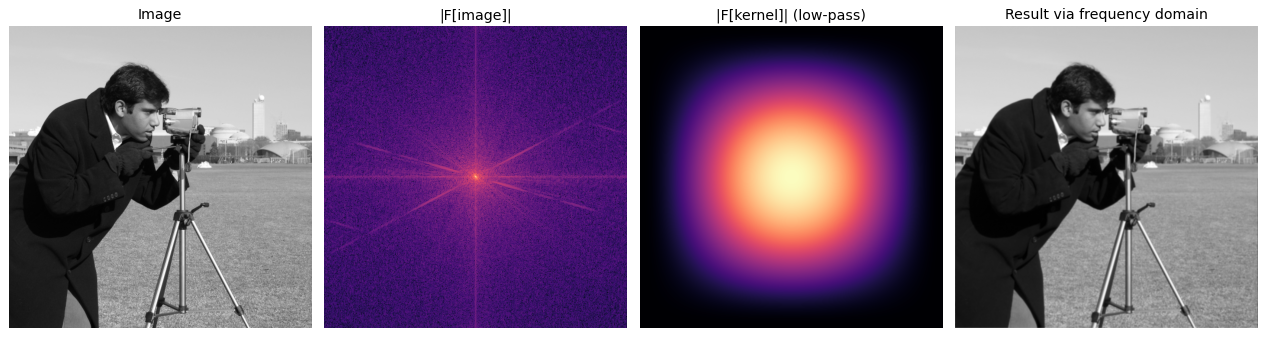

In [9]:
img = load_gray(data.camera())
k   = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], float) / 16   # small Gaussian kernel

# place the kernel at the array origin so the FFT product is a centred convolution
H = np.zeros_like(img); H[:3, :3] = k; H = np.roll(H, (-1, -1), axis=(0, 1))
spatial = ndimage.convolve(img, k, mode='wrap')
freq    = np.real(np.fft.ifft2(np.fft.fft2(img) * np.fft.fft2(H)))
print('max |spatial - frequency|:', np.abs(spatial - freq).max())

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
show(ax[0], img, 'Image')
show(ax[1], log_mag(img), '|F[image]|', spectrum=True)
show(ax[2], log_mag(H), '|F[kernel]| (low-pass)', spectrum=True)
show(ax[3], freq, 'Result via frequency domain')
plt.tight_layout(); plt.show()

## 7. Properties of the Fourier transform

| Property | Signal | Transform |
|---|---|---|
| superposition | $f_1 + f_2$ | $F_1 + F_2$ |
| shift | $f(x - x_0)$ | $F(\omega)\,e^{-j\omega x_0}$ |
| convolution | $f * h$ | $F\,H$ |
| correlation | $f \otimes h$ | $F\,H^{*}$ |
| multiplication | $f\,h$ | $F * H$ |
| differentiation | $f'(x)$ | $j\omega F$ |
| Parseval | $\sum_x f(x)^2$ | $\tfrac{1}{N}\sum_\omega \lvert F(\omega)\rvert^2$ |

Two are easy to verify numerically: a shift leaves the **magnitude** unchanged (it only adds linear phase), and
Parseval says energy is preserved between the two domains.

In [10]:
img = load_gray(data.camera())
F   = np.fft.fft2(img)
Fs  = np.fft.fft2(np.roll(img, (40, 25), axis=(0, 1)))     # circular shift

print('shift keeps magnitude:  max | |F| - |F_shift| | =', np.abs(np.abs(F) - np.abs(Fs)).max())
print('Parseval ratio (freq energy / spatial energy)   =',
      (np.sum(np.abs(F)**2) / img.size) / np.sum(img**2))

shift keeps magnitude:  max | |F| - |F_shift| | = 3.637978807091713e-12
Parseval ratio (freq energy / spatial energy)   = 1.0000000000000002


## 8. Low-pass and high-pass filtering in the frequency domain

A **low-pass** filter keeps frequencies near the centre (smooth content) and blocks the rest, so it blurs; a
**high-pass** filter keeps the outer frequencies (fine detail) and blocks the centre, so it isolates edges. The
Gaussian is a smooth low-pass filter and an edge filter is high-pass. An **ideal** (hard-edged) mask is the
obvious choice, but its sharp cutoff introduces ringing (the 2D Gibbs phenomenon) that a Gaussian mask avoids.

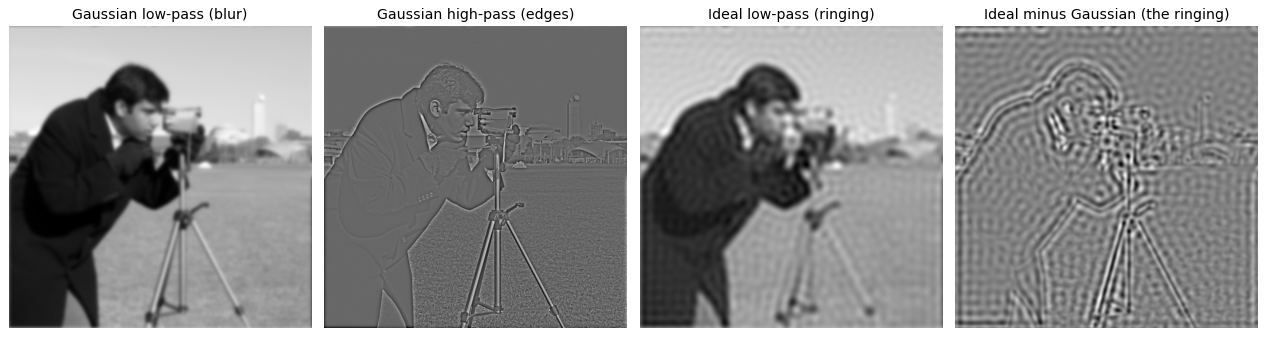

In [11]:
img  = load_gray(data.camera())
N    = img.shape[0]
F    = np.fft.fftshift(np.fft.fft2(img))
Y, X = np.ogrid[:N, :N]
R    = np.hypot(Y - N//2, X - N//2)          # distance from centre = frequency
cut  = 30

def apply(mask):
    return np.real(np.fft.ifft2(np.fft.ifftshift(F * mask)))

ideal_lp = (R <= cut).astype(float)
gauss_lp = np.exp(-R**2 / (2*cut**2))
gauss_hp = 1 - gauss_lp

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
show(ax[0], apply(gauss_lp), 'Gaussian low-pass (blur)')
show(ax[1], apply(gauss_hp), 'Gaussian high-pass (edges)')
show(ax[2], apply(ideal_lp), 'Ideal low-pass (ringing)')
show(ax[3], apply(ideal_lp) - apply(gauss_lp), 'Ideal minus Gaussian (the ringing)')
plt.tight_layout(); plt.show()

## 9. Which carries more: magnitude or phase?

Split two images into magnitude and phase, then swap: reconstruct one image's **magnitude** with the other's
**phase**. The result follows the phase. Phase encodes where edges and structure sit, while magnitude records
how much energy each frequency carries, so phase is what we read as the content.

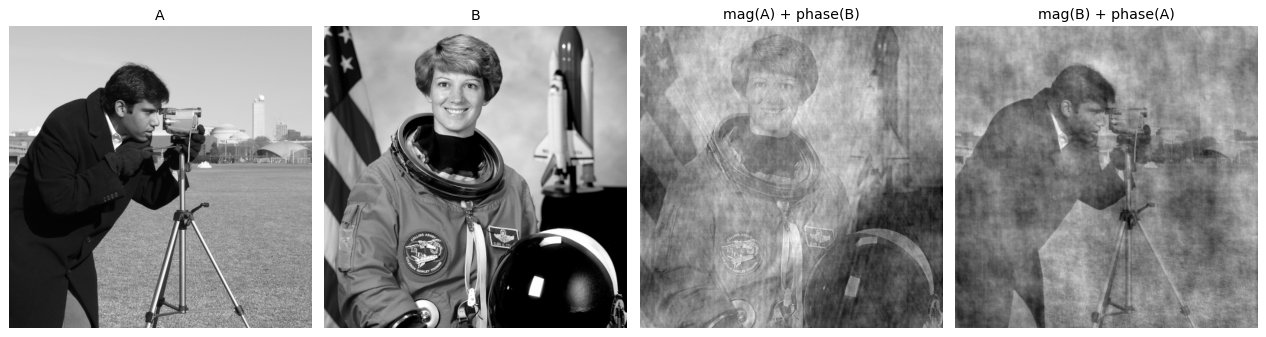

In [12]:
A = load_gray(data.camera())
B = load_gray(data.astronaut())          # both 512 x 512

FA, FB = np.fft.fft2(A), np.fft.fft2(B)
magA, phA = np.abs(FA), np.angle(FA)
magB, phB = np.abs(FB), np.angle(FB)
mix1 = np.real(np.fft.ifft2(magA * np.exp(1j*phB)))   # magnitude of A, phase of B
mix2 = np.real(np.fft.ifft2(magB * np.exp(1j*phA)))   # magnitude of B, phase of A

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
show(ax[0], A, 'A')
show(ax[1], B, 'B')
show(ax[2], mix1, 'mag(A) + phase(B)')
show(ax[3], mix2, 'mag(B) + phase(A)')
plt.tight_layout(); plt.show()

## 10. Hybrid images

A **hybrid image** sums the low frequencies of one picture and the high frequencies of another. Up close the eye
resolves the fine (high-frequency) detail; from far away only the coarse (low-frequency) content survives, so
the two pictures swap (Oliva, Torralba and Schyns, SIGGRAPH 2006). How well the subjects are aligned controls
how convincing the illusion is.

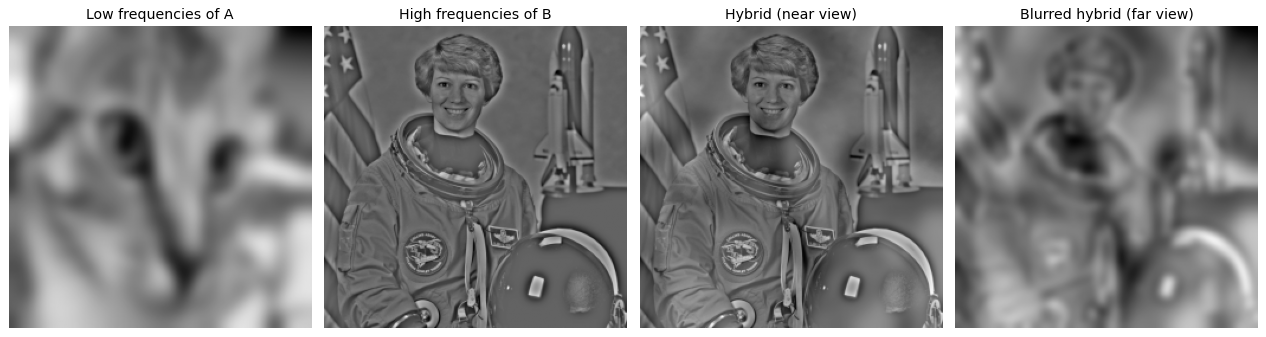

In [13]:
A = load_gray(data.chelsea(), size=256)      # supplies the low frequencies
B = load_gray(data.astronaut(), size=256)    # supplies the high frequencies

low    = ndimage.gaussian_filter(A, 6)
high   = B - ndimage.gaussian_filter(B, 4)
hybrid = low + high
far    = ndimage.gaussian_filter(hybrid, 4)  # viewing distance acts like a low-pass

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
show(ax[0], low, 'Low frequencies of A')
show(ax[1], high, 'High frequencies of B')
show(ax[2], hybrid, 'Hybrid (near view)')
show(ax[3], far, 'Blurred hybrid (far view)')
plt.tight_layout(); plt.show()

## 11. Exercise: match each image to its spectrum

Below are five spatial images (A-E) and their magnitude spectra in a shuffled order (1-5). Predict the pairing
from the rules above (orientation maps to peak direction, frequency to peak distance, smoothness to a compact
centre), then run the next cell to check.

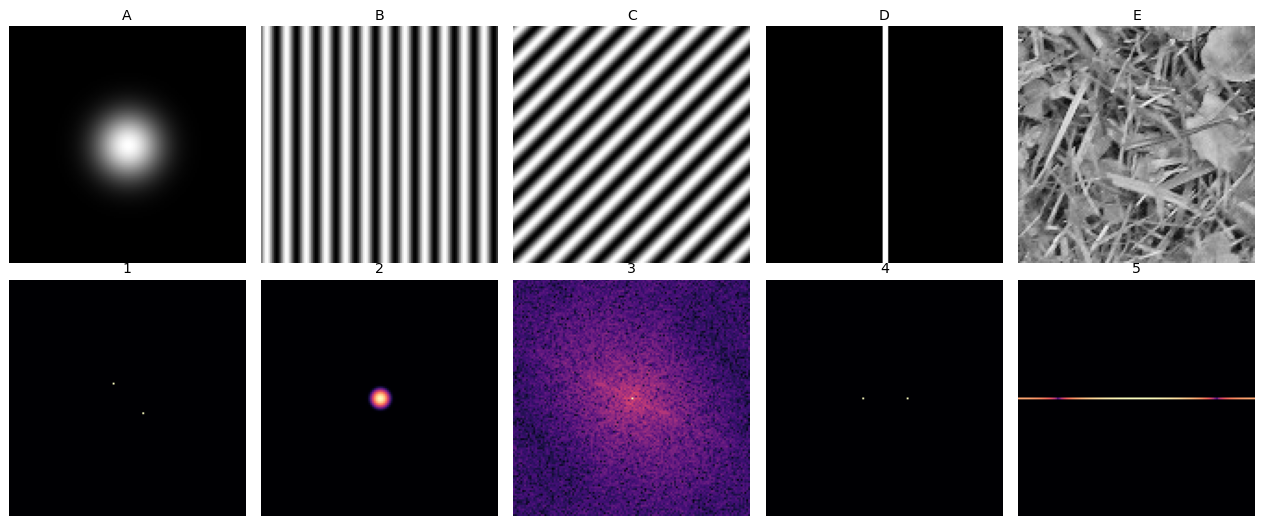

In [14]:
n = 128
yy, xx = np.mgrid[0:n, 0:n]
images = {
    'A': np.exp(-((xx-n/2)**2 + (yy-n/2)**2) / (2*12**2)),   # smooth blob
    'B': np.sin(2*np.pi*12*xx/n),                            # vertical grating
    'C': np.sin(2*np.pi*8*(xx+yy)/n),                        # diagonal grating
    'D': (np.abs(xx - n/2) < 2).astype(float),              # single vertical line
    'E': load_gray(data.grass())[:n, :n],                   # natural texture
}
order   = ['C', 'A', 'E', 'B', 'D']                          # shuffled spectrum order
spectra = {str(i+1): log_mag(images[k]) for i, k in enumerate(order)}

fig, ax = plt.subplots(2, 5, figsize=(15, 6.2))
for j, k in enumerate('ABCDE'):
    show(ax[0, j], images[k], k)
for j, k in enumerate(['1', '2', '3', '4', '5']):
    show(ax[1, j], spectra[k], k, spectrum=True)
plt.tight_layout(); plt.show()

In [15]:
answer = {k: str(order.index(k) + 1) for k in 'ABCDE'}
print('image -> spectrum:', answer)

image -> spectrum: {'A': '2', 'B': '4', 'C': '1', 'D': '5', 'E': '3'}


---

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **Template matching** | Normalised cross-correlation scores pattern presence in $[-1,1]$ and peaks at matches |
| **Median filter** | Nonlinear; removes salt-and-pepper outliers that linear smoothers only spread |
| **Bilateral filter** | Nonlinear and edge-preserving; a domain kernel times a range kernel down-weights dissimilar neighbours |
| **Fourier series** | Any signal is a weighted sum of sinusoids; a square wave is $\frac{4}{\pi}\sum_{k\,\text{odd}}\frac{1}{k}\sin(2\pi k t)$ |
| **Image spectrum** | A grating maps to symmetric peaks; distance gives frequency, direction gives orientation, centre is DC |
| **Magnitude vs phase** | Magnitude is energy per frequency; phase carries the structure we perceive |
| **Convolution theorem** | $\mathcal{F}[g*h]=\mathcal{F}[g]\mathcal{F}[h]$; filtering is multiplication in the frequency domain |
| **FFT** | Computes the DFT in $O(N\log N)$ instead of $O(N^2)$ |
| **Low/high-pass** | Keep the centre to blur, keep the outside for edges; ideal masks ring, Gaussian masks do not |
| **Hybrid images** | Low frequencies of one image plus high frequencies of another swap with viewing distance |

**Reading:** Szeliski, *Computer Vision: Algorithms and Applications*, Ch. 3.4.

**References:** J. Hays (Georgia Tech); D. Hoiem (UIUC); A. Oliva, A. Torralba and P. Schyns, "Hybrid Images",
SIGGRAPH 2006; Forsyth and Ponce, *Computer Vision: A Modern Approach*, 2003.